<a href="https://colab.research.google.com/github/Elsaterziu/ml-project/blob/feature%2Fpreprocessing-logistic-regression/notebooks/patient_no_show_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving appointments.csv to appointments.csv


In [ ]:
import pandas as pd

df = pd.read_csv("appointments.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


ScheduledDay      0
AppointmentDay    0
dtype: int64


,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,WaitingDays,AppointmentWeekDay,ScheduledHour,NoShow
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,4,18,0
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,4,16,0
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,4,16,0
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,4,17,0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,4,16,0


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110521 entries, 0 to 110526
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Gender              110521 non-null  object
 1   Age                 110521 non-null  int64 
 2   Neighbourhood       110521 non-null  object
 3   Scholarship         110521 non-null  int64 
 4   Hypertension        110521 non-null  int64 
 5   Diabetes            110521 non-null  int64 
 6   Alcoholism          110521 non-null  int64 
 7   Handicap            110521 non-null  int64 
 8   SMS_received        110521 non-null  int64 
 9   WaitingDays         110521 non-null  int64 
 10  AppointmentWeekDay  110521 non-null  int32 
 11  ScheduledHour       110521 non-null  int32 
 12  NoShow              110521 non-null  int64 
dtypes: int32(2), int64(9), object(2)
memory usage: 11.0+ MB


In [ ]:
df_cleaned.isnull().sum()

,0
Gender,0
Age,0
Neighbourhood,0
Scholarship,0
Hypertension,0
Diabetes,0
Alcoholism,0
Handicap,0
SMS_received,0
WaitingDays,0


In [ ]:
df_cleaned.shape

(110521, 13)

In [ ]:
df_cleaned.to_csv("appointments_cleaned.csv", index=False)

In [ ]:
from google.colab import files
files.download("appointments_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving appointments_cleaned.csv to appointments_cleaned.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("appointments_cleaned.csv")
df.head()

,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,WaitingDays,AppointmentWeekDay,ScheduledHour,NoShow
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,4,18,0
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,4,16,0
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,4,16,0
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,4,17,0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,4,16,0


## Preprocessing and Logistic Regression

In [4]:
X = df.drop("NoShow", axis=1)
y = df["NoShow"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (110521, 12)
y shape: (110521,)


In [5]:
numeric_features = [
    "Age",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap",
    "SMS_received",
    "WaitingDays",
    "AppointmentWeekDay",
    "ScheduledHour"
]

categorical_features = [
    "Gender",
    "Neighbourhood"
]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (88416, 12)
Testing set: (22105, 12)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Scholarship',
                                                   'Hypertension', 'Diabetes',
                                                   'Alcoholism', 'Handicap',
                                                   'SMS_received',
                                                   'WaitingDays',
                                                   'AppointmentWeekDay',
                                                   'ScheduledHour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Neighbourhood'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_logistic = logistic_model.predict(X_test)

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_logistic),
    "Precision": precision_score(y_test, y_pred_logistic, zero_division=0),
    "Recall": recall_score(y_test, y_pred_logistic, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_logistic, zero_division=0)
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7955666138882606,
 'Precision': 0.3627450980392157,
 'Recall': 0.016580775263275824,
 'F1-score': 0.03171202056995929}

In [16]:
print(classification_report(y_test, y_pred_logistic, zero_division=0))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.36      0.02      0.03      4463

    accuracy                           0.80     22105
   macro avg       0.58      0.50      0.46     22105
weighted avg       0.71      0.80      0.71     22105



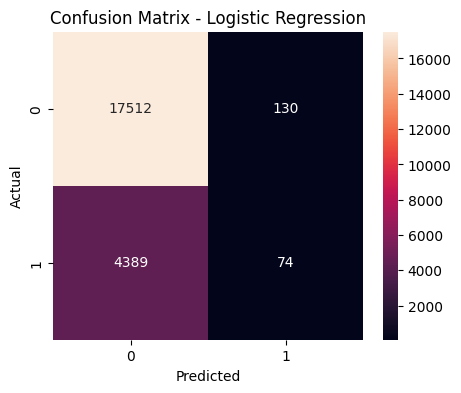

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()